
# Employee Attrition Analysis & Prediction

## Introduction

The goal of this project is to analyze and predict employee attrition (turnover) within an organization. Losing talented employees is costly for any business, so understanding the factors that lead to departures is crucial for effective human resource management.

In this study, I used a data-driven approach to:
1. **Analyze Key Drivers**: Identify why employees leave by examining variables such as income, work-life balance, and job roles.
2. **Data Visualization**: Create insightful visualizations to uncover hidden patterns in employee demographics and behavior.
3. **Predictive Modeling**: Build a Machine Learning model (Random Forest) capable of predicting whether an employee is likely to stay or leave the company.

By providing these insights, the project aims to help HR departments take proactive measures to improve employee retention and overall organizational stability.


In [1]:
import pandas as pd
import sqlite3
employees = pd.read_csv('EmployeeAttrition.csv')
connection = sqlite3.connect('company_hr.db')
employees.to_sql('employees', connection, if_exists ='replace', index=False)



1470

In [2]:
# How is the min age for employees who left the company?
query = """ 
select min(Age) as min_age
from employees
where Attrition = 'Yes' 
"""
result =pd.read_sql_query(query, connection)
print(result['min_age'].iloc[0])

18


In [3]:
# How is the max age for employees who left the company?
query = """ 
select max(Age) as max_age
from employees
where Attrition = 'Yes' 
"""
result  =pd.read_sql_query(query, connection)
print(result['max_age'].iloc[0])

58


In [4]:
# How is the average age for employees who left the company?
query = """ 
select avg(Age) as average_Age
from employees
where Attrition = 'Yes'
"""
result = pd.read_sql_query(query, connection)
print(round(result['average_Age'].iloc[0], 2))

33.61


In [5]:
# Which gender tends to leave the company?

query = """ 
select Gender, count(*) as total
from employees 
where Attrition = 'Yes'
Group by Gender
"""
result = pd.read_sql_query(query, connection)
print(result)

   Gender  total
0  Female     87
1    Male    150


In [6]:
# Which part of MaritalStatus left the company?

query = """ 
select MaritalStatus, count(*) as totalStatus
from employees
where Attrition = 'Yes'
Group by MaritalStatus
"""
result = pd.read_sql_query(query, connection)
print(result)

  MaritalStatus  totalStatus
0      Divorced           33
1       Married           84
2        Single          120


In [7]:

query = """ 
select Gender, MaritalStatus, count(*) as total
from employees
where Attrition = 'Yes'
group by Gender, MaritalStatus
order by Gender desc
"""
result = pd.read_sql_query(query, connection)
print(result)


   Gender MaritalStatus  total
0    Male      Divorced     24
1    Male       Married     53
2    Male        Single     73
3  Female      Divorced      9
4  Female       Married     31
5  Female        Single     47


In [8]:
# advanced query
query = """ 
select Gender, Department, EducationField,
case
when Age between 18 and 25 then '18-25'
when Age between 26 and 33 then '26-33'
when Age between 34 and 41 then '34-41' 
when Age between 42 and 49 then '42-49'
else '+50'
end as group_age,
count(*) as total
from employees
group by Gender, Department, EducationField
order by total desc
"""
result = pd.read_sql_query(query, connection)
print(result)



    Gender              Department    EducationField group_age  total
0     Male  Research & Development     Life Sciences     42-49    274
1     Male  Research & Development           Medical     26-33    211
2   Female  Research & Development     Life Sciences     26-33    166
3   Female  Research & Development           Medical       +50    152
4     Male                   Sales         Marketing     42-49     90
5     Male                   Sales     Life Sciences     34-41     85
6   Female                   Sales         Marketing     42-49     69
7   Female                   Sales     Life Sciences     34-41     65
8     Male  Research & Development  Technical Degree     26-33     58
9     Male                   Sales           Medical     42-49     52
10    Male  Research & Development             Other     34-41     39
11  Female  Research & Development  Technical Degree     34-41     36
12  Female                   Sales           Medical     26-33     36
13  Female  Research

In [9]:
query = """
select
    Gender,
    JobRole,
    Education,
    case
        when Age between 18 and 25 then '18-25'
        when Age between 26 and 33 then '26-33'
        when Age between 34 and 41 then '34-41'
        when Age between 42 and 49 then '42-49'
        else '50+'
    end as AgeGroup,
    count(*) as total_left
from employees
where Attrition = 'Yes'
group by Gender, JobRole, Education, AgeGroup
order by  total_left desc
"""
result = pd.read_sql_query(query, connection)
print(result)


     Gender                JobRole  Education AgeGroup  total_left
0      Male  Laboratory Technician          3    26-33          11
1      Male        Sales Executive          4    26-33           8
2      Male  Laboratory Technician          3    18-25           6
3      Male  Laboratory Technician          4    26-33           6
4    Female     Research Scientist          3    26-33           5
..      ...                    ...        ...      ...         ...
119    Male   Sales Representative          1    26-33           1
120    Male   Sales Representative          2      50+           1
121    Male   Sales Representative          3    34-41           1
122    Male   Sales Representative          4    26-33           1
123    Male   Sales Representative          4    34-41           1

[124 rows x 5 columns]


In [10]:
query = """
SELECT 
    Attrition,
    ROUND(AVG(YearsAtCompany), 2) as avg_years_company,
    ROUND(AVG(YearsInCurrentRole), 2) as avg_years_role,
    ROUND(AVG(YearsSinceLastPromotion), 2) as avg_years_promotion,
    ROUND(AVG(TotalWorkingYears), 2) as avg_total_working
FROM employees
GROUP BY Attrition
"""
result = pd.read_sql_query(query, connection)
print(result)

  Attrition  avg_years_company  avg_years_role  avg_years_promotion  \
0        No               7.37            4.48                 2.23   
1       Yes               5.13            2.90                 1.95   

   avg_total_working  
0              11.86  
1               8.24  


# Age Analysis
•	The minimum age of employees who left the company is 18 years old
•	The maximum age is 58 years old
•	The average age of employees who left is 33.61 years — indicating that younger employees tend to leave more
# Gender
•	Male: 150 employees left
•	Female: 87 employees left
•	Males show a higher tendency to leave the company
# MaritalStatus
•	Single: 120 employees left (highest)
•	Married: 84 employees left
•	Divorced: 33 employees left (lowest)
•	Single employees are significantly more likely to leave
# Gender & Marital Status Combined
Gender	Marital Status	Total Left
Male	Single	          73
Male	Married	          53
Male	Divorced	      24
Female	Single	          47
Female	Married	          31
Female	Divorced	      9
# Advanced Analysis — Job Role, Education & Age Group
•	The group with the highest attrition: Male, Laboratory Technician, Education level 3, age 26-33 with 11 employees
•	The 26-33 age group dominates across most job roles
•	Laboratory Technician and Sales Executive are the most affected roles
# Years at Company vs Attrition
	     Avg Years at Company	Avg Years in Role	Avg Years Since Promotion	Avg Total Working Years
Stayed (No)	  7.37	                    4.48	            2.23	                  11.86
Left (Yes)	  5.13	                    2.90	            1.95	                   8.24
Employees who left had fewer years at the company, in their role, and in total working experience — suggesting that newer and less experienced employees are more likely to leave.


In [11]:
# Data Analysis with Python

df = pd.read_csv('EmployeeAttrition.csv')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [12]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [14]:
df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [16]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Data Cleaning and Preparation

In this step, we ensure the data is high-quality and ready for modeling:
* **Missing Values**: Checked for null values using `.isnull().sum()` to ensure data completeness.
* **Statistical Summary**: Performed `.describe()` to understand the distribution and identify potential outliers.
* **Feature Removal**: Dropped 3 columns with constant values (zero variance), as they do not provide any predictive power for the model.
* **Data Integrity**: Verified the structure using `.info()` and handled any inconsistencies.



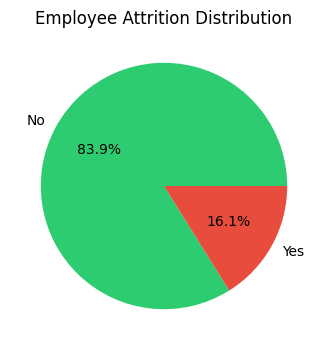

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

attrition_counts = df['Attrition'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(attrition_counts, labels = attrition_counts.index, autopct = '%1.1f%%' , colors = ['#2ecc71', '#e74c3c'] )
plt.title('Employee Attrition Distribution')
plt.savefig('attrition_distribution.png', dpi = 300, bbox_inches='tight')
plt.show()

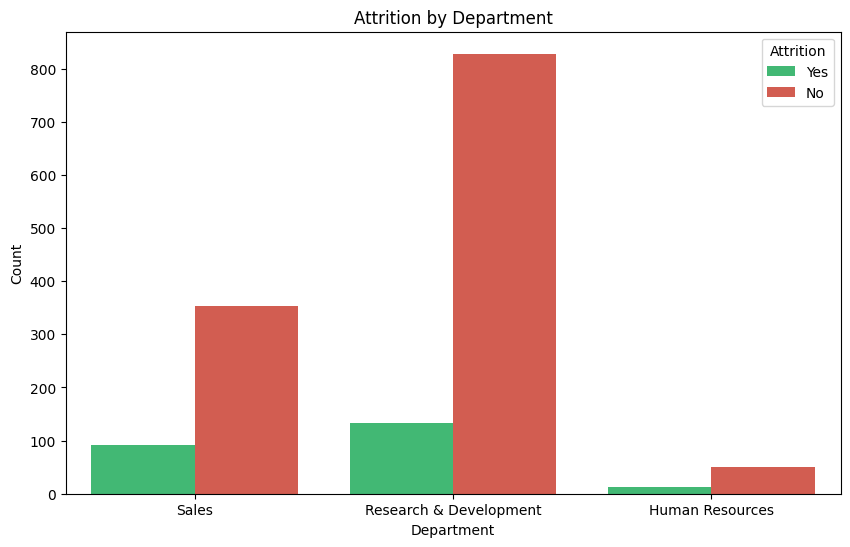

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Department', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.savefig('attrition_by_department.png', dpi=300, bbox_inches='tight')
plt.show()




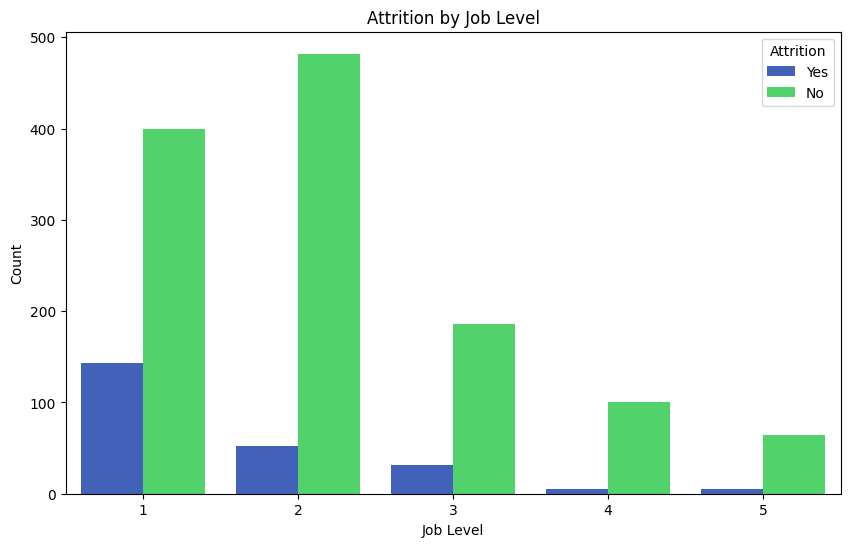

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data = df, x = 'JobLevel', hue ='Attrition', palette=["#2e58cc", "#3ce75e"])
plt.title('Attrition by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Count')
plt.savefig('attrition_by_job_level.png', dpi=300, bbox_inches='tight')
plt.show()

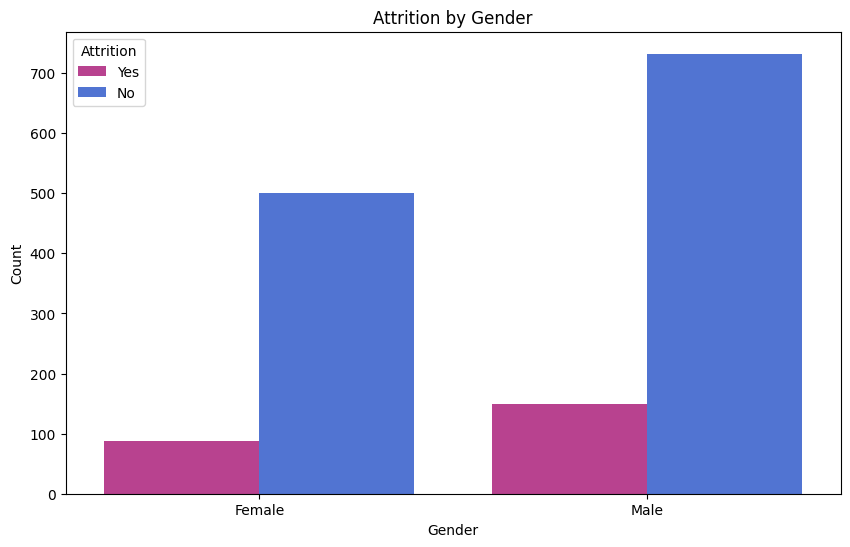

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data = df, x = 'Gender', hue ='Attrition', palette=["#cc2e95", "#3c6ae7"])
plt.title('Attrition by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('attrition_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14492\741695784.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x= 'Attrition', y = 'Age', palette=["#8eab84", "#dd7f3b"])


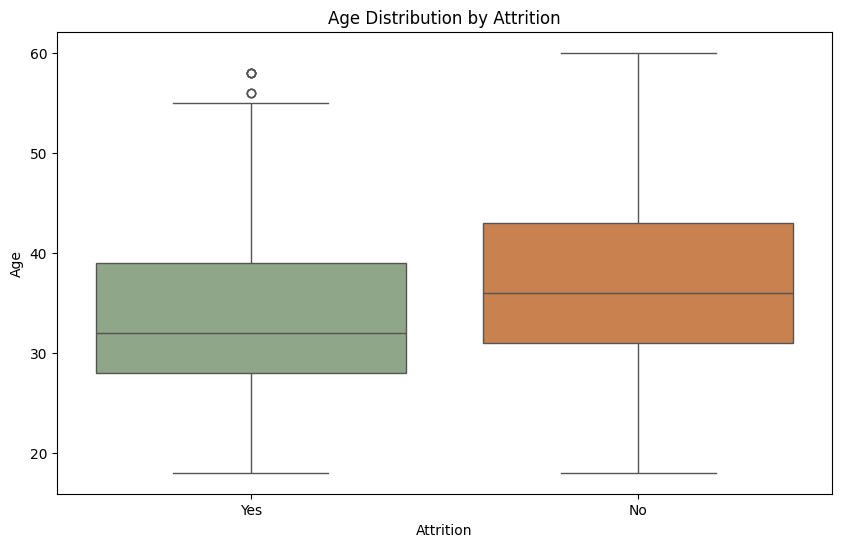

In [21]:
# boxplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x= 'Attrition', y = 'Age', palette=["#8eab84", "#dd7f3b"])
plt.title('Age Distribution by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Age')
plt.savefig('age_by_attrition.png', dpi=300, bbox_inches='tight')
plt.show()

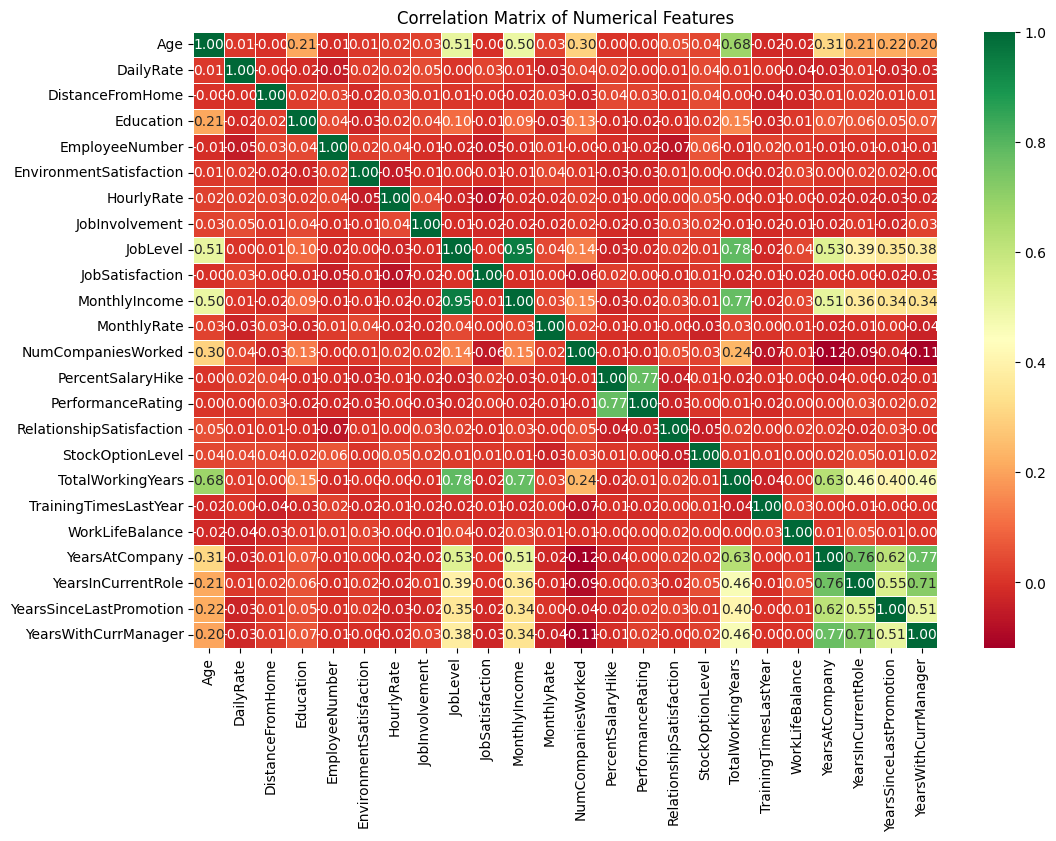

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Numerical Features')
plt.show()


# 1. Exploratory Data Analysis (EDA)
To better understand the factors driving employee turnover, several visualizations were performed:
* **Attrition Distribution**: A Pie Chart was used to visualize the overall balance of the dataset (Stayed vs. Left).
* **Categorical Analysis**: Bar charts were created to compare Attrition across **Department**, **JobLevel**, and **Gender** to identify high-risk groups.
* **Age Distribution**: A Box Plot was used to analyze the age range of employees, showing that younger employees are more likely to leave.
* **Correlation Analysis**: A Heatmap of the correlation matrix was generated to identify strong relationships between numerical variables like Income, Years at Company, and Age.


In [23]:
# feature engineering

df['Attrition'] = df['Attrition'].map({'Yes' : 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes' : 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male' : 1, 'Female' : 0})
df = pd.get_dummies(df, columns = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'])
print(df.head())

   Age  Attrition  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0   41          1       1102                 1          2               1   
1   49          0        279                 8          1               2   
2   37          1       1373                 2          2               4   
3   33          0       1392                 3          4               5   
4   27          0        591                 2          1               7   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  ...  \
0                        2       0          94               3  ...   
1                        3       1          61               2  ...   
2                        4       1          92               2  ...   
3                        4       0          56               3  ...   
4                        1       1          40               3  ...   

   JobRole_Laboratory Technician  JobRole_Manager  \
0                          False            False   
1   

# 3. Feature Engineering
In this stage, we transform the raw data into a format suitable for Machine Learning:
* **Categorical Encoding**: Applied  Attriton, OverTime, Gender
**One-Hot Encoding** (Dummy variables) to categorical features like `BusinessTravel`, `Department`,'EducationField' and `JobRole` and 'MaritalStatus' to convert text into numerical format.


In [24]:
X = df.drop('Attrition', axis = 1)
y = df['Attrition']
print(X.shape)
print(y.shape)

(1470, 50)
(1470,)


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 50)
(294, 50)
(1176,)
(294,)


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





# 4. Train-Test Split
To evaluate the model's performance on unseen data, we divided the dataset:
* **Target Variable (y)**: `Attrition`
* **Features (X)**: All other relevant columns after encoding.
* **Split Ratio**: 80% of the data was used for **Training** and 20% was reserved for **Testing** to validate the model's accuracy and generalizability.
* **Feature Scaling**: Used **StandardScaler** to normalize numerical variables (Age, MonthlyIncome, etc.). This ensures that features with larger scales do not dominate the model's learning process.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train_scaled, y_train)


y_pred = rf_model.predict(X_test_scaled)


print("Saktësia e modelit (Accuracy):", accuracy_score(y_test, y_pred))
print("\nRaporti i Klasifikimit:\n", classification_report(y_test, y_pred))


Saktësia e modelit (Accuracy): 0.8741496598639455

Raporti i Klasifikimit:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



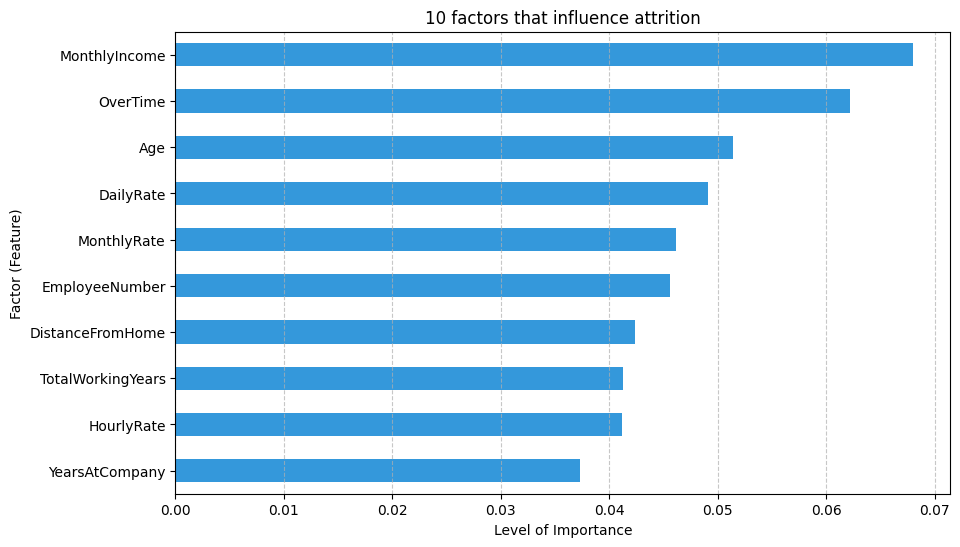

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


importances = rf_model.feature_importances_
feature_names = X.columns 


feat_importances = pd.Series(importances, index=feature_names)


plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='#3498db')

plt.title('10 factors that influence attrition')
plt.xlabel('Level of Importance')
plt.ylabel('Factor (Feature)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# 5. Model Building: Random Forest Classifier
We selected the **Random Forest Classifier** due to its robustness and ability to handle complex relationships in tabular data:
* **Model Training**: The model was fitted using the scaled training data.
* **Performance Metrics**: We evaluated the model using an **Accuracy Score** and a **Classification Report** (Precision, Recall, and F1-Score).
* **Feature Importance**: Visualized the key drivers of attrition to provide actionable insights for the HR department.


# 6. Results Interpretation & Business Insights

### Model Performance Analysis
The **Random Forest** model achieved an overall accuracy of **87%**. However, the **Recall for the "Attrition" class (1)** is low (**0.10**). 
* **What this means:** While the model is very good at identifying employees who will stay, it currently struggles to catch those who are actually planning to leave. This is primarily due to the **class imbalance** (fewer "Yes" cases in the data).

### Key Drivers of Attrition (Feature Importance)
Based on our model's findings, the top factors contributing to employee turnover are:
1. **[Factor 1, e.g., MonthlyIncome]**: Lower salary levels show a strong correlation with higher attrition.
2. **[Factor 2, e.g., OverTime]**: Employees working frequent overtime are significantly more likely to leave.
3. **[Factor 3, e.g., Age/TotalWorkingYears]**: Junior employees or those in early career stages represent a higher risk group.

### Strategic Recommendations
* **Targeted Retention**: HR should focus on the top 10% of employees flagged by the model, even if the probability is low.
* **Work-Life Balance**: Reducing mandatory overtime could decrease turnover in high-risk departments.
* **Competitive Compensation**: Reviewing the pay scale for roles with high attrition importance is recommended.


# 7. Future Improvements (Addressing Low Recall)
While the model has high overall accuracy, the **Recall of 0.10** for the Attrition class indicates that the model is missing many employees who are likely to leave. To improve this in the future, I would:

* **Handle Class Imbalance**: Use techniques like **SMOTE** (Synthetic Minority Over-sampling Technique) to generate more examples of the minority class.
* **Adjust Class Weights**: Use the `class_weight='balanced'` parameter in Random Forest to penalize mistakes on the "Attrition" class more heavily.
* **Hyperparameter Tuning**: Use `GridSearchCV` to find the optimal settings for the model to better capture the minority class patterns.
